# imports

In [1]:
import cv2
from correspondance import find_correspondences,plot_correspondences
from homography import compute_homography, verify_homography
from corners import get_book_corners_in_frame, draw_book_outline
from crop import crop_ar_frame
import matplotlib.pyplot as plt

### 1- Augmented Reality with Planar Homographies

In [ ]:
book_img   = cv2.imread("materials/cv_cover.jpg")          # static book cover image
book_cap   = cv2.VideoCapture("materials/book.mov")
ar_cap     = cv2.VideoCapture("materials/ar_source.mov")

ret1, book_frame = book_cap.read()           # first frame of book video
ret2, ar_frame   = ar_cap.read()             # first frame of AR source video

if not (ret1 and ret2):
        raise IOError("Could not read video frames — check file paths.")


### 1.1- Getting Correspondences

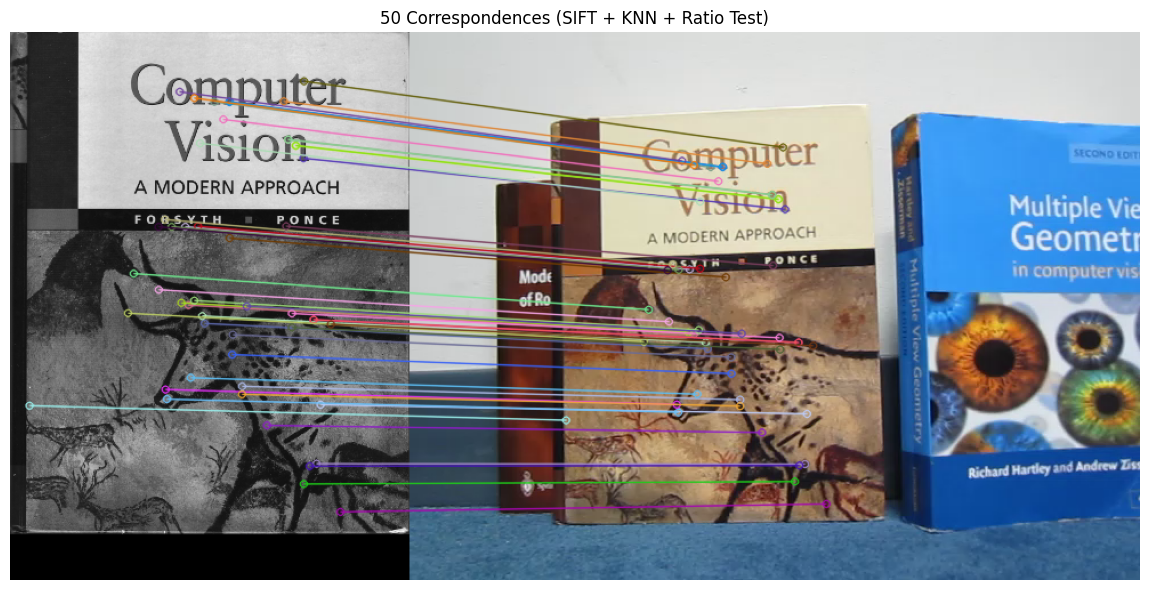

In [4]:
pts1, pts2, kp1, kp2, good = find_correspondences(book_img, book_frame, n=50)
plot_correspondences(book_img, book_frame, kp1, kp2, good)

#### 2.2 - Compute the Homography Parameters

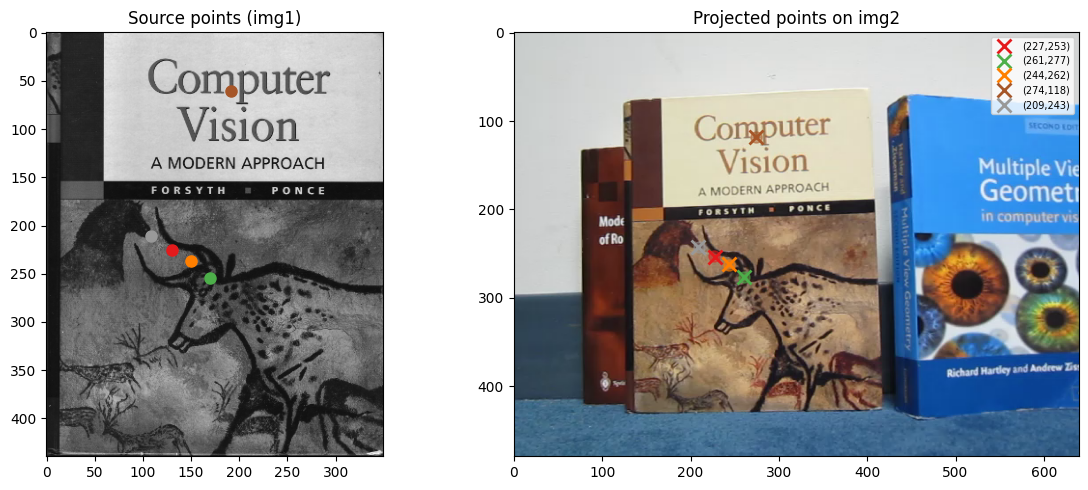

In [5]:
H = compute_homography(pts1, pts2)
verify_homography(H, pts1, pts2, book_img, book_frame)

#### 1.3 - Calculate Book Coordinates

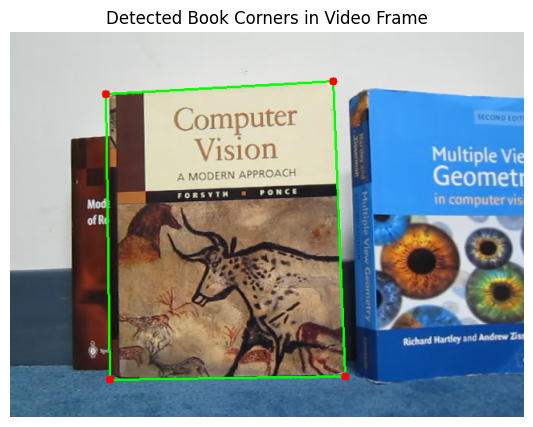

In [6]:
book_corners = get_book_corners_in_frame(H, book_img)
vis = draw_book_outline(book_frame.copy(), book_corners)
plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("Detected Book Corners in Video Frame")
plt.axis("off")
plt.show()

#### 1.4 - Crop Ar Video Frames

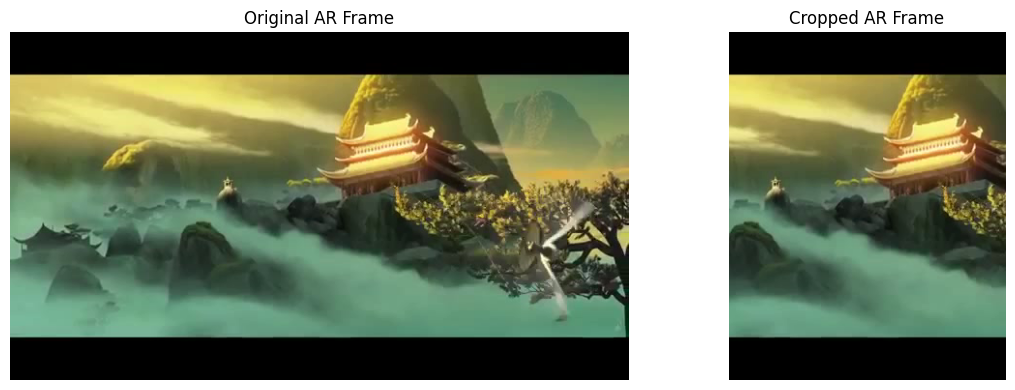

In [7]:
cropped_ar = crop_ar_frame(ar_frame, book_corners) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(ar_frame,   cv2.COLOR_BGR2RGB)); axes[0].set_title("Original AR Frame")
axes[1].imshow(cv2.cvtColor(cropped_ar, cv2.COLOR_BGR2RGB)); axes[1].set_title("Cropped AR Frame")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()
book_cap.release()
ar_cap.release()